In [1]:
!pip install fastf1
import fastf1
import os
import pandas as pd
import numpy as np

cache_path = r'C:\Users\elesn\Downloads\Szakdoga\cache'
os.makedirs(cache_path, exist_ok=True)

fastf1.Cache.enable_cache(cache_path)


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
years = range(2018, 2024)
all_data = []

for year in years:
    session = fastf1.get_session(year, 'Bahrain', 'R')
    session.load()

    laps = session.laps.copy()
    weather = session.weather_data.copy()

    laps = pd.merge_asof(laps.sort_values('Time'),weather.sort_values('Time'),on='Time',direction='backward') #idő szerint illesztjük össze a két adattáblát
    #minden körhöz tartozni fog a hozzá időben legközelebb álló időjárási adat

    laps['Year'] = year

    all_data.append(laps)

#df = pd.concat(all_data)
#df = df[df['Driver'] == 'VER'].copy() #itt konkrétan egy pilótát választok ki, a későbbiekben ezt fogom megvizsgálni több versenyzőre
#print(df.columns)
#df.head()
df = pd.concat(all_data, ignore_index=True)

# csak a 2023-as szezon kiértékelésre
#df_2023 = df_all[df_all['Year'] == 2023].copy()

print(df.columns)
df.head()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
core        WARNING 	Car telemetry data is unavailable!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
core        WARNING 	Car position data is unavailable!
core        WARNING 	Failed to determine `Session.t0_date`!
logger      WARNING 	Failed to load telemetry data!
req    

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity', 'Pressure',
       'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'Year'],
      dtype='object')


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FastF1Generated,IsAccurate,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,Year
0,0 days 00:09:12.347000,VET,5,0 days 00:01:35.238000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:40.676000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
1,0 days 00:09:13.814000,BOT,77,0 days 00:01:36.705000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.160000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
2,0 days 00:09:14.770000,RAI,7,0 days 00:01:37.661000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.537000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
3,0 days 00:09:15.824000,RIC,3,0 days 00:01:38.684000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:41.585000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018
4,0 days 00:09:17.432000,GAS,10,0 days 00:01:40.323000,1.0,NaN,NaT,NaT,NaT,0 days 00:00:42.641000,...,False,False,28.1,45.9,1009.3,False,33.2,355,1.6,2018


In [3]:
# csak normál versenykörök
fit_df = df.copy()

fit_df = fit_df.dropna(
    subset=['TyreLife', 'LapTime']
)

# másodperces köridő
fit_df['LapTimeSeconds'] = (
    fit_df['LapTime']
    .dt.total_seconds()
)

# opcionális outlier szűrés
fit_df = fit_df[
    fit_df['LapTimeSeconds']
    < fit_df['LapTimeSeconds'].quantile(0.99)
]

# x és y változók
tyre_life = fit_df['TyreLife']
lap_time = fit_df['LapTimeSeconds']

# harmadfokú polinom illesztés
coeffs = np.polyfit(
    tyre_life,
    lap_time,
    3
)

# polyfit fordított sorrendben adja vissza
c3, c2, c1, c0 = coeffs

print("Polynomial coefficients:")
print("c0 =", c0)
print("c1 =", c1)
print("c2 =", c2)
print("c3 =", c3)

Polynomial coefficients:
c0 = 110.50549320789051
c1 = -2.291065176542186
c2 = 0.12872564836815711
c3 = -0.0020651267649616956


In [4]:
#paraméterek:
MU_0 = 85
PIT_LOSS = 21
g = 0.03

# üzemanyag fogyasztás
c_t = {
    1: 1.92,   # soft
    2: 1.87,   # medium
    3: 1.83    # hard
}

# gumikopás
d_t = {
    1: 1/25,
    2: 1/40,
    3: 1/65
}

# gumikeverékekek teljesítményvesztesége (s/lap)
alpha_t = {
    1: 0.0,
    2: 0.6,
    3: 0.9
}


In [5]:
from dataclasses import dataclass

@dataclass(frozen=True)
class State:

    tire: int
    wear: float
    fuel: float
    used_two_compounds: int
    lap: int

In [6]:
def mu(state, action):

    t = state.tire
    w = state.wear
    f = state.fuel

    pit_penalty = PIT_LOSS if action != 0 else 0
    # compound baseline
    compound_effect = alpha_t[t]
    # spline / polynomial degradation
    degradation = (
        c0
        + c1 * w
        + c2 * (w ** 2)
        + c3 * (w ** 3)
    )

    # fuel effect
    fuel_effect = 0.03 * f

    lap_time = (
        degradation
        + compound_effect
        + fuel_effect
        + pit_penalty
    )

    #lap_time = (MU_0+ alpha_t[t]+ g * w * f+ pit_penalty)

    return lap_time

In [7]:

def transition(state, action):

    t = state.tire
    w = state.wear
    f = state.fuel
    m = state.used_two_compounds
    lap = state.lap

    # fuel update
    fuel_next = max(
        0,
        f - c_t[t]
    )

    # no pit stop
    if action == 0:

        tire_next = t

        wear_next = min(
            1,
            w + d_t[t]
        )

        m_next = m

    # pit stop
    else:

        tire_next = action

        wear_next = 0

        if action != t:
            m_next = 1
        else:
            m_next = m

    return State(
        tire=tire_next,
        wear=wear_next,
        fuel=fuel_next,
        used_two_compounds=m_next,
        lap=lap + 1
    )

In [ ]:
ACTIONS = [0, 1, 2, 3]
#dp:
from functools import lru_cache
@lru_cache(None)
def V(state):

    # race finished
    if state.lap > TOTAL_LAPS:

        # FIA rule
        if state.used_two_compounds == 0:
            return 1e6

        return 0

    best_value = float('inf')

    for action in ACTIONS:

    # stay out always allowed
        if action == 0:
            pass

    # pit stop
        else:

        # opcionális tiltás
            if action == state.tire and state.wear < 0.5:
                continue
        lap_cost = mu(state, action)

        next_state = transition(state, action)

        total_cost = lap_cost + V(next_state)

        best_value = min(
            best_value,
            total_cost
        )

    return best_value

In [9]:
initial_state = State(
    tire=2,          # medium
    wear=0.0,
    fuel=100,
    used_two_compounds=0,
    lap=1
)

def optimal_strategy(initial_state, total_laps):

    strategy = []

    state = initial_state

    while state.lap <= total_laps:

        best_action = None
        best_value = float('inf')

        for action in ACTIONS:

            # STAY OUT
            if action == 0:

                value = (
                    mu(state, action)
                    +
                    V(transition(state, action))
                )

            # PIT STOP
            else:

                # opcionális tiltás:
                # ne rakjon fel ugyanolyat túl korán
                if (
                    action == state.tire
                    and state.wear < 0.5
                ):
                    continue

                value = (
                    mu(state, action)
                    +
                    V(transition(state, action))
                )

            # LEGJOBB ACTION KIVÁLASZTÁSA
            if value < best_value:

                best_value = value
                best_action = action

        # stratégia mentése
        strategy.append(
            (state.lap, best_action)
        )

        # állapotfrissítés
        state = transition(
            state,
            best_action
        )

    return strategy

#strategy = optimal_strategy(
#    initial_state,
#    TOTAL_LAPS
#)

#print(strategy)

In [10]:
def simulate_race(initial_state, strategy):

    state = initial_state

    total_time = 0

    lap_times = []

    for lap, action in strategy:

        # aktuális köridő
        lap_time = mu(state, action)

        lap_times.append(lap_time)

        total_time += lap_time

        # következő állapot
        state = transition(state, action)

    return total_time, lap_times

In [ ]:
evaluation_df = df.copy()

evaluation_df = evaluation_df[
    evaluation_df['Year'] == 2023
].copy()

drivers = sorted(evaluation_df['Driver'].unique())

results = []
all_strategies = {}
all_laps = {}
all_initial_states = {}

for driver in drivers:

    print("\n====================")
    print("Driver:", driver)

    driver_df = evaluation_df[
        evaluation_df['Driver'] == driver
    ].copy()

    if driver_df.empty:
        continue

    # körszám driverenként
    global TOTAL_LAPS
    TOTAL_LAPS = int(driver_df['LapNumber'].max())
    V.cache_clear()

    for start_tire_name, start_tire_id in {
        "SOFT": 1,
        "MEDIUM": 2,
        "HARD": 3
    }.items():
    # kezdeti állapot reset
        initial_state = State(
        tire=start_tire_id,
        wear=0.0,
        fuel=100,
        used_two_compounds=0,
        lap=1
    )

    # DP stratégia
    strategy = optimal_strategy(initial_state,TOTAL_LAPS)
    all_strategies[(driver, start_tire_name)] = strategy
    all_laps[(driver, start_tire_name)] = TOTAL_LAPS
    all_initial_states[(driver, start_tire_name)] = start_tire_id

    # model szimuláció
    model_time, lap_times = simulate_race(
        initial_state,
        strategy
    )

    # real time 
    real_time = (driver_df['LapTime'].dt.total_seconds().sum())

    # regret
    regret = real_time - model_time

    # relative regret
    relative_regret = (
        regret
        / real_time
    )

    results.append({
        "Driver": driver,
        "RealTime": real_time,
        "ModelTime": model_time,
        "Regret": regret,
        "RelativeRegret": relative_regret
    })

    results_df = pd.DataFrame(results)
    print(results_df)

    #átlagolt regret:
    avg_regret = (
        results_df['Regret']
        .mean()
    )

    avg_relative_regret = (
       results_df['RelativeRegret']
       .mean()
   )

    print("\nAVERAGE REGRET:", avg_regret)

    print(
       "AVERAGE RELATIVE REGRET:",
       avg_relative_regret
) 


Driver: ALB
  Driver  RealTime  ModelTime    Regret  RelativeRegret
0    ALB   5726.51  6306.8887 -580.3787       -0.101349

AVERAGE REGRET: -580.378700381184
AVERAGE RELATIVE REGRET: -0.10134946073283449

Driver: ALO
  Driver  RealTime  ModelTime    Regret  RelativeRegret
0    ALB  5726.510  6306.8887 -580.3787       -0.101349
1    ALO  5675.373  6306.8887 -631.5157       -0.111273

AVERAGE REGRET: -605.9472003811838
AVERAGE RELATIVE REGRET: -0.10631122336706969

Driver: BOT
  Driver  RealTime  ModelTime    Regret  RelativeRegret
0    ALB  5726.510  6306.8887 -580.3787       -0.101349
1    ALO  5675.373  6306.8887 -631.5157       -0.111273
2    BOT  5709.383  6306.8887 -597.5057       -0.104653

AVERAGE REGRET: -603.1333670478501
AVERAGE RELATIVE REGRET: -0.1057585780683881

Driver: DEV
  Driver  RealTime    ModelTime      Regret  RelativeRegret
0    ALB  5726.510  6306.888700 -580.378700       -0.101349
1    ALO  5675.373  6306.888700 -631.515700       -0.111273
2    BOT  5709.383  

In [15]:
results_df = pd.DataFrame(results)

print(results_df)

avg_regret = results_df["Regret"].mean()

print("AVG REGRET:", avg_regret)

   Driver  RealTime    ModelTime      Regret  RelativeRegret
0     ALB  5726.510  6306.526300 -580.016300       -0.101286
1     ALO  5675.373  6306.526300 -631.153300       -0.111209
2     BOT  5709.383  6306.526300 -597.143300       -0.104590
3     DEV  5659.259  6198.185212 -538.926212       -0.095229
4     GAS  5710.489  6306.526300 -596.037300       -0.104376
5     HAM  5687.713  6306.526300 -618.813300       -0.108798
6     HUL  5660.647  6198.185212 -537.538212       -0.094961
7     LEC  3886.118  4460.153095 -574.035095       -0.147714
8     MAG  5653.493  6198.185212 -544.692212       -0.096346
9     NOR  5643.372  6089.844123 -446.472123       -0.079114
10    OCO  4219.566  4569.191684 -349.625684       -0.082858
11    PER  5648.723  6306.526300 -657.803300       -0.116452
12    PIA  1342.585  1486.751840 -144.166840       -0.107380
13    RUS  5692.609  6306.526300 -613.917300       -0.107845
14    SAI  5684.788  6306.526300 -621.738300       -0.109369
15    SAR  5637.872  619

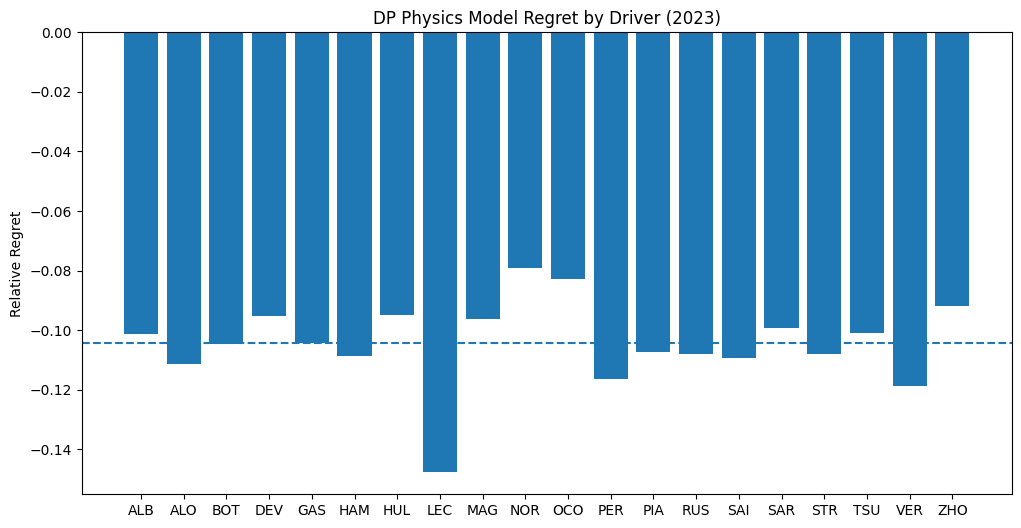

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Driver"],
    results_df['RelativeRegret']
)

plt.axhline(avg_relative_regret, linestyle="--",label='Average Relative Regret')

plt.title("DP Physics Model Regret by Driver (2023)")
plt.ylabel("Relative Regret")

plt.show()

In [17]:
#stratégiából stint-ek meghatározása
def strategy_to_stints(strategy, initial_tire, total_laps):

    tire_names = {
        1: "SOFT",
        2: "MEDIUM",
        3: "HARD"
    }

    current_tire = tire_names[initial_tire]
    stint_start = 1

    stints = []

    for lap, action in strategy:

        # pit stop
        if action != 0:

            stints.append(
                (
                    stint_start,
                    lap - stint_start,
                    current_tire
                )
            )

            current_tire = tire_names[action]
            stint_start = lap

    # utolsó stint
    stints.append(
        (
            stint_start,
            total_laps - stint_start + 1,
            current_tire
        )
    )

    return stints

In [18]:
#pit körök kigyűjtése
pit_laps = [
    lap
    for lap, action in strategy
    if action != 0
]

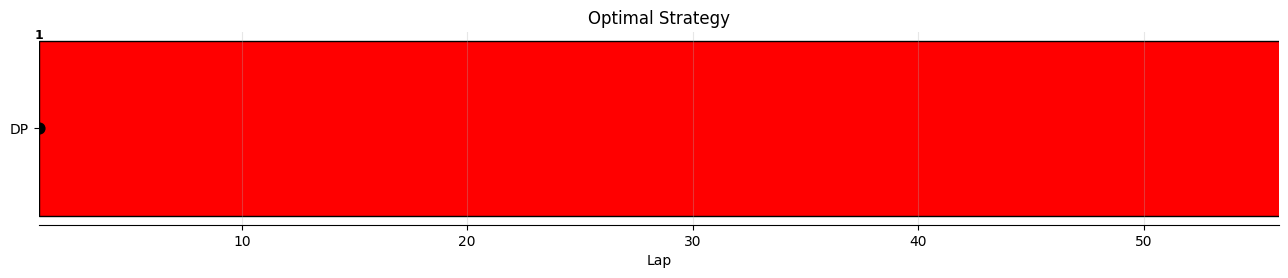

In [ ]:
#ábrázolás
import matplotlib.pyplot as plt

driver = "VER"
start_tire = "MEDIUM"   # vagy SOFT / HARD

# --- adatok betöltése a dictből ---
strategy = all_strategies[(driver, start_tire)]
TOTAL_LAPS = all_laps[(driver, start_tire)]

# ha van ilyened:
initial_tire_id = all_initial_states[(driver, start_tire)]

# --- stint rekonstruálás ---
stints = strategy_to_stints(
    strategy,
    initial_tire=initial_tire_id,
    total_laps=TOTAL_LAPS
)

# --- pit stopok (NINCS PIT_LAPS globálisan → innen számoljuk) ---
pit_laps = [
    lap for lap, action in strategy if action != 0
]

# --- színek ---
colors = {
    "SOFT": "red",
    "MEDIUM": "gold",
    "HARD": "lightgray"
}

# --- plot ---
fig, ax = plt.subplots(figsize=(16, 2.5))

for start, length, compound in stints:

    ax.barh(
        y=0,
        width=length,
        left=start,
        height=0.35,
        color=colors[compound],
        edgecolor="black"
    )

# --- pit stop pontok ---
for lap in pit_laps:

    ax.scatter(
        lap,
        0,
        color="black",
        s=60,
        zorder=5
    )

    ax.text(
        lap,
        0.18,
        str(lap),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# --- layout ---
ax.set_xlim(1, TOTAL_LAPS)

ax.set_yticks([0])
ax.set_yticklabels([driver])

ax.set_xlabel("Lap")
ax.set_title(f"{driver} - {start_tire} Strategy")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.3)

plt.show()